# Scratch TFLite Model Evaluation

이 노트북은 `data/models/scratch/` 에 저장된 모든 `.tflite` 모델을 자동 발견해서 **embedding 품질**을 정량적으로 비교한다.

## 평가 지표

| 지표 | 측정 대상 | 좋은 값 |
|---|---|---|
| **1. Pair discrimination** | 학습 loss가 직접 관심 있는 것 — 같은 동작은 cos↑, 다른 동작은 cos↓ | `gap ↑`, `AUC ↑` |
| **2. Temporal smoothness** | 연속된 프레임의 embedding이 매끈하게 흐르는가 | `cos(E(t), E(t+k))` 가 k에 따라 매끈 감소 |
| **3. Noise robustness** | MediaPipe jitter를 모사한 Gaussian noise에서 embedding이 안정적인가 | σ가 커져도 `cos(E_clean, E_noisy)` 가 높게 유지 |
| 4. Top-1 retrieval (참고) | 5개 춤 중 정답 춤이 1위인 비율 | 간접 지표 |

Baseline으로 **`direct_frame`** (마지막 프레임만 쓰는 cosine) 과 **`direct_window`** (30프레임 window flatten cosine) 를 함께 넣어 학습된 모델이 이들보다 얼마나 나은지 본다.

## 0. 환경 설정

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'scripts' / 'train_scratch_similarity.py').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError('pjt_main project root를 찾지 못했습니다.')

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import tensorflow as tf
from pose.landmark_utils import DANCE_JOINTS
from scoring.scratch_features import build_pose_window, normalize_pose_landmarks

MODELS_DIR = PROJECT_ROOT / 'data' / 'models' / 'scratch'
REFERENCES_DIR = PROJECT_ROOT / 'data' / 'reference_dances'

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'MODELS_DIR   = {MODELS_DIR}')
print(f'TensorFlow   = {tf.__version__}')

2026-04-15 22:33:03.596168: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-15 22:33:03.611164: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-15 22:33:03.611185: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-15 22:33:03.622292: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 22:33:04.175833: W tensorflow/compiler/tf

PROJECT_ROOT = /workspace/users/yijin/boot_env/pjt_main
MODELS_DIR   = /workspace/users/yijin/boot_env/pjt_main/data/models/scratch
TensorFlow   = 2.16.2


## 1. 평가 파라미터

각 지표의 sample 수, stride, window sigma 등을 한곳에 모아둔다. 아래 값들은 실행 시간 10~60초 정도를 타겟한 기본값. 모델이 많아지면 `n_pairs_per_dance`, `smoothness_segment_length`, `n_noise_windows` 를 줄이면 됨.

In [2]:
EVAL = {
    # 데이터 split
    'train_ratio':      0.7,       # 앞 70% gallery/train-like, 뒤 30% held-out eval
    'default_seq_len':  30,        # meta.json에서 못 읽을 때 fallback
    'default_feat_dims': 2,
    'seed':             42,

    # [지표 1] Pair discrimination
    'positive_jitter':  6,
    'negative_gap':     600,
    'n_pairs_per_dance': 80,       # 각 타입(pos/neg/hard_neg)별

    # [지표 2] Temporal smoothness
    'smoothness_segment_length': 300,   # 각 춤에서 최대 300프레임짜리 연속 구간
    'smoothness_ks':    [1, 5, 15, 30, 60, 120],

    # [지표 3] Noise robustness
    'n_noise_windows':  60,
    'noise_sigmas':     [0.01, 0.03, 0.05, 0.1],

    # [지표 4] Top-1 retrieval
    'retrieval_query_stride':   15,
    'retrieval_gallery_stride': 6,

    # Direct baseline 포함 여부
    'include_direct_frame':   True,
    'include_direct_window':  True,
}

rng = np.random.default_rng(EVAL['seed'])
print(json.dumps(EVAL, indent=2))

{
  "train_ratio": 0.7,
  "default_seq_len": 30,
  "default_feat_dims": 2,
  "seed": 42,
  "positive_jitter": 6,
  "negative_gap": 600,
  "n_pairs_per_dance": 80,
  "smoothness_segment_length": 300,
  "smoothness_ks": [
    1,
    5,
    15,
    30,
    60,
    120
  ],
  "n_noise_windows": 60,
  "noise_sigmas": [
    0.01,
    0.03,
    0.05,
    0.1
  ],
  "retrieval_query_stride": 15,
  "retrieval_gallery_stride": 6,
  "include_direct_frame": true,
  "include_direct_window": true
}


## 2. Reference 데이터 로딩

In [3]:
references = {}
for d in sorted(REFERENCES_DIR.iterdir()):
    npy = d / 'reference.npy'
    if not npy.exists():
        continue
    seq = np.load(npy).astype(np.float32)
    if seq.ndim != 3 or seq.shape[1] < 29:
        print(f'[SKIP] {d.name}: invalid shape {seq.shape}')
        continue
    if seq.shape[2] == 3:
        vis = np.ones((*seq.shape[:2], 1), dtype=np.float32)
        seq = np.concatenate([seq, vis], axis=2)
    seq = np.nan_to_num(seq)
    references[d.name] = seq
    split_idx = int(len(seq) * EVAL['train_ratio'])
    print(f'  {d.name:16s} frames={len(seq):5d}  '
          f'gallery=[0, {split_idx}), eval=[{split_idx}, {len(seq)})')

assert references, 'reference.npy 파일이 필요합니다.'

  beginner_wave    frames= 1800  gallery=[0, 1260), eval=[1260, 1800)
  cheerup_dance    frames=  724  gallery=[0, 506), eval=[506, 724)
  freestyle_free   frames= 3600  gallery=[0, 2520), eval=[2520, 3600)
  hiphop_move      frames=  792  gallery=[0, 554), eval=[554, 792)
  kpop_basic       frames= 2700  gallery=[0, 1889), eval=[1889, 2700)


## 3. 모델 발견 + 공통 embedder 인터페이스

`MODELS_DIR` 에서 `.tflite` 를 모두 스캔하고 각각의 meta.json 에서 `sequence_length`, `feature_dims`, `loss_type` 을 읽는다. Direct baseline과 함께 `methods` 리스트로 묶어 이후 평가에서 순회한다.

모든 embedder는 `window: (T, J, C) → l2-normalized embedding` 계약을 따른다. 덕분에 cosine = dot product 로 단순화됨.

In [4]:
def l2norm(v, eps=1e-8):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(n, eps)


def make_interpreter(tflite_path):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    return interp


def _tflite_embed(interp, window):
    in_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    tensor = window[None, ...].astype(np.float32)
    if not np.issubdtype(in_det['dtype'], np.floating):
        scale, zero = in_det.get('quantization', (0.0, 0))
        if scale:
            q = np.round(tensor / scale + zero)
            info = np.iinfo(in_det['dtype'])
            tensor = np.clip(q, info.min, info.max).astype(in_det['dtype'])
    interp.set_tensor(in_det['index'], tensor)
    interp.invoke()
    out = interp.get_tensor(out_det['index'])
    if not np.issubdtype(out.dtype, np.floating):
        scale, zero = out_det.get('quantization', (0.0, 0))
        if scale:
            out = (out.astype(np.float32) - zero) * scale
    return out.reshape(-1).astype(np.float32)


methods = []

if EVAL['include_direct_frame']:
    methods.append({
        'name':     'direct_frame',
        'loss':     '-',
        'seq_len':  EVAL['default_seq_len'],  # window를 받지만 마지막 frame만 씀
        'embed':    lambda w: l2norm(w[-1].flatten()),
    })
if EVAL['include_direct_window']:
    methods.append({
        'name':     'direct_window',
        'loss':     '-',
        'seq_len':  EVAL['default_seq_len'],
        'embed':    lambda w: l2norm(w.flatten()),
    })

# scratch TFLite 자동 발견
for tflite_path in sorted(MODELS_DIR.glob('*.tflite')):
    meta_path = tflite_path.with_name(f'{tflite_path.stem}_meta.json')
    meta = json.loads(meta_path.read_text('utf-8')) if meta_path.exists() else {}
    cfg = meta.get('config', {})
    interp = make_interpreter(tflite_path)
    methods.append({
        'name':     tflite_path.stem,
        'loss':     cfg.get('loss_type', 'bce'),
        'seq_len':  int(cfg.get('sequence_length', EVAL['default_seq_len'])),
        'feat_dims': int(cfg.get('feature_dims', EVAL['default_feat_dims'])),
        'meta':     meta,
        'embed':    (lambda w, interp=interp: l2norm(_tflite_embed(interp, w))),
    })

print(f'총 {len(methods)}개 method 준비됨:')
for m in methods:
    print(f'  {m["name"]:30s} loss={m["loss"]:7s} seq_len={m["seq_len"]}')

총 10개 method 준비됨:
  direct_frame                   loss=-       seq_len=30
  direct_window                  loss=-       seq_len=30
  my_gcn_e32_bce                 loss=bce     seq_len=30
  my_gcn_e32_triplet             loss=triplet seq_len=30
  my_gcn_e64_bce                 loss=bce     seq_len=30
  my_gcn_e64_triplet             loss=triplet seq_len=30
  my_tcn_e32_bce                 loss=bce     seq_len=30
  my_tcn_e32_triplet             loss=triplet seq_len=30
  my_tcn_e64_bce                 loss=bce     seq_len=30
  my_tcn_e64_triplet             loss=triplet seq_len=30


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 4. Window 추출 Helper

여러 지표가 같은 held-out 범위에서 window를 요구한다. `valid_eval_end_range` 는 "window가 완전히 held-out 구간 안에 들어가도록" end_idx 범위를 돌려준다.

In [5]:
def valid_eval_end_range(dance_name, seq_length):
    seq = references[dance_name]
    split = int(len(seq) * EVAL['train_ratio'])
    lo = max(split + seq_length - 1, seq_length - 1)
    hi = len(seq) - 1
    if lo > hi:
        return None
    return lo, hi


def make_window(dance_name, end_idx, seq_length, feature_dims):
    return build_pose_window(
        references[dance_name], end_idx, seq_length,
        target_joints=DANCE_JOINTS, feature_dims=feature_dims,
    )


# Sanity check
for d in references:
    er30 = valid_eval_end_range(d, 30)
    print(f'  {d:16s}  eval end 범위 (seq_len=30) = {er30}')

  beginner_wave     eval end 범위 (seq_len=30) = (1289, 1799)
  cheerup_dance     eval end 범위 (seq_len=30) = (535, 723)
  freestyle_free    eval end 범위 (seq_len=30) = (2549, 3599)
  hiphop_move       eval end 범위 (seq_len=30) = (583, 791)
  kpop_basic        eval end 범위 (seq_len=30) = (1918, 2699)


## 5. 지표 1 — Pair Discrimination

**무엇을 보나**: 학습이 강제한 pairwise metric이 held-out에서도 유지되는가.

- **positive**: 같은 춤의 `±positive_jitter` 프레임 이내 두 window (진짜 "같은 동작")
- **negative**: 서로 다른 춤의 임의 window (확실한 "다른 동작")
- **hard_negative**: 같은 춤이지만 `≥negative_gap` 프레임 떨어짐 (같은 style / 다른 동작)

**기대 값**:
- `mean_pos` ↑ (1에 가까움), `mean_neg` ↓ (음수 or 0 근처), `mean_hard_neg` 는 중간
- **`gap = mean_pos - mean_neg`**: 클수록 discriminative
- **`AUC`**: pos vs neg를 cosine으로 분류했을 때 ROC AUC. 1.0이면 완벽 분리

In [6]:
# --- Pair sampling (seq_length는 method마다 다를 수 있으므로 method별로 샘플링) ---
def sample_pairs(seq_length):
    dances = list(references.keys())
    positive, negative, hard_negative = [], [], []

    for d in dances:
        er = valid_eval_end_range(d, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(EVAL['n_pairs_per_dance']):
            end_a = int(rng.integers(lo, hi + 1))
            delta = int(rng.integers(-EVAL['positive_jitter'], EVAL['positive_jitter'] + 1))
            end_b = int(np.clip(end_a + delta, lo, hi))
            positive.append((d, end_a, d, end_b))

    for _ in range(len(dances) * EVAL['n_pairs_per_dance']):
        d_a, d_b = rng.choice(dances, size=2, replace=False)
        er_a = valid_eval_end_range(d_a, seq_length)
        er_b = valid_eval_end_range(d_b, seq_length)
        if er_a is None or er_b is None:
            continue
        end_a = int(rng.integers(er_a[0], er_a[1] + 1))
        end_b = int(rng.integers(er_b[0], er_b[1] + 1))
        negative.append((d_a, end_a, d_b, end_b))

    for d in dances:
        er = valid_eval_end_range(d, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(EVAL['n_pairs_per_dance']):
            end_a = int(rng.integers(lo, hi + 1))
            for _ in range(20):
                end_b = int(rng.integers(lo, hi + 1))
                if abs(end_a - end_b) >= EVAL['negative_gap']:
                    break
            hard_negative.append((d, end_a, d, end_b))

    return positive, negative, hard_negative


def compute_pair_cosines(method, pairs):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    cache = {}

    def get_emb(dance, end):
        key = (dance, end)
        if key not in cache:
            w = make_window(dance, end, seq_length, feat_dims)
            cache[key] = method['embed'](w)
        return cache[key]

    cos_list = []
    for d_a, end_a, d_b, end_b in pairs:
        e_a = get_emb(d_a, end_a)
        e_b = get_emb(d_b, end_b)
        cos_list.append(float(np.dot(e_a, e_b)))
    return np.array(cos_list, dtype=np.float32)


def roc_auc_numpy(pos_scores, neg_scores):
    """sklearn 없이 numpy로 ROC AUC 계산 (Mann-Whitney U / trapz 방식)."""
    y_true  = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_score = np.concatenate([pos_scores, neg_scores])
    order   = np.argsort(y_score)[::-1]
    y_sorted = y_true[order]
    n_pos = y_sorted.sum()
    n_neg = len(y_sorted) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    tpr = np.concatenate([[0.0], np.cumsum(y_sorted)     / n_pos])
    fpr = np.concatenate([[0.0], np.cumsum(1 - y_sorted) / n_neg])
    return float(np.trapz(tpr, fpr))


try:
    from sklearn.metrics import roc_auc_score as _sklearn_auc
    def compute_auc(pos_cos, neg_cos):
        labels = np.concatenate([np.ones(len(pos_cos)), np.zeros(len(neg_cos))])
        scores = np.concatenate([pos_cos, neg_cos])
        return float(_sklearn_auc(labels, scores))
    print('[AUC] sklearn 사용')
except ImportError:
    def compute_auc(pos_cos, neg_cos):
        return roc_auc_numpy(pos_cos, neg_cos)
    print('[AUC] sklearn 없음 → numpy fallback 사용')


# --- 실행: 모든 method에 대해 세 pair 타입의 cosine 수집 ---
results_pair = {}
for method in methods:
    # seed는 method마다 같은 pair를 쓰도록 고정
    rng = np.random.default_rng(EVAL['seed'])
    pos_pairs, neg_pairs, hneg_pairs = sample_pairs(method['seq_len'])
    pos_cos = compute_pair_cosines(method, pos_pairs)
    neg_cos = compute_pair_cosines(method, neg_pairs)
    hneg_cos = compute_pair_cosines(method, hneg_pairs)
    gap = float(pos_cos.mean() - neg_cos.mean())
    auc = compute_auc(pos_cos, neg_cos)
    results_pair[method['name']] = {
        'pos': pos_cos, 'neg': neg_cos, 'hneg': hneg_cos,
        'mean_pos': float(pos_cos.mean()),
        'mean_neg': float(neg_cos.mean()),
        'mean_hneg': float(hneg_cos.mean()),
        'gap': gap,
        'auc': auc,
    }
    auc_str = f'{auc:.3f}' if np.isfinite(auc) else '  -  '
    print(f'  {method["name"]:30s}  pos={pos_cos.mean():+.3f}  '
          f'neg={neg_cos.mean():+.3f}  hneg={hneg_cos.mean():+.3f}  '
          f'gap={gap:+.3f}  auc={auc_str}')


[AUC] sklearn 없음 → numpy fallback 사용
  direct_frame                    pos=+0.387  neg=+0.060  hneg=+0.309  gap=+0.328  auc=0.674
  direct_window                   pos=+0.407  neg=+0.069  hneg=+0.294  gap=+0.337  auc=0.690
  my_gcn_e32_bce                  pos=+0.917  neg=-0.034  hneg=+0.337  gap=+0.950  auc=0.986
  my_gcn_e32_triplet              pos=+0.951  neg=+0.059  hneg=+0.410  gap=+0.891  auc=0.996
  my_gcn_e64_bce                  pos=+0.902  neg=-0.036  hneg=+0.286  gap=+0.938  auc=0.983
  my_gcn_e64_triplet              pos=+0.960  neg=+0.327  hneg=+0.534  gap=+0.632  auc=0.990
  my_tcn_e32_bce                  pos=+0.930  neg=-0.002  hneg=+0.334  gap=+0.932  auc=0.985
  my_tcn_e32_triplet              pos=+0.942  neg=+0.030  hneg=+0.378  gap=+0.912  auc=0.994
  my_tcn_e64_bce                  pos=+0.918  neg=-0.072  hneg=+0.306  gap=+0.990  auc=0.990
  my_tcn_e64_triplet              pos=+0.948  neg=+0.101  hneg=+0.477  gap=+0.847  auc=0.993


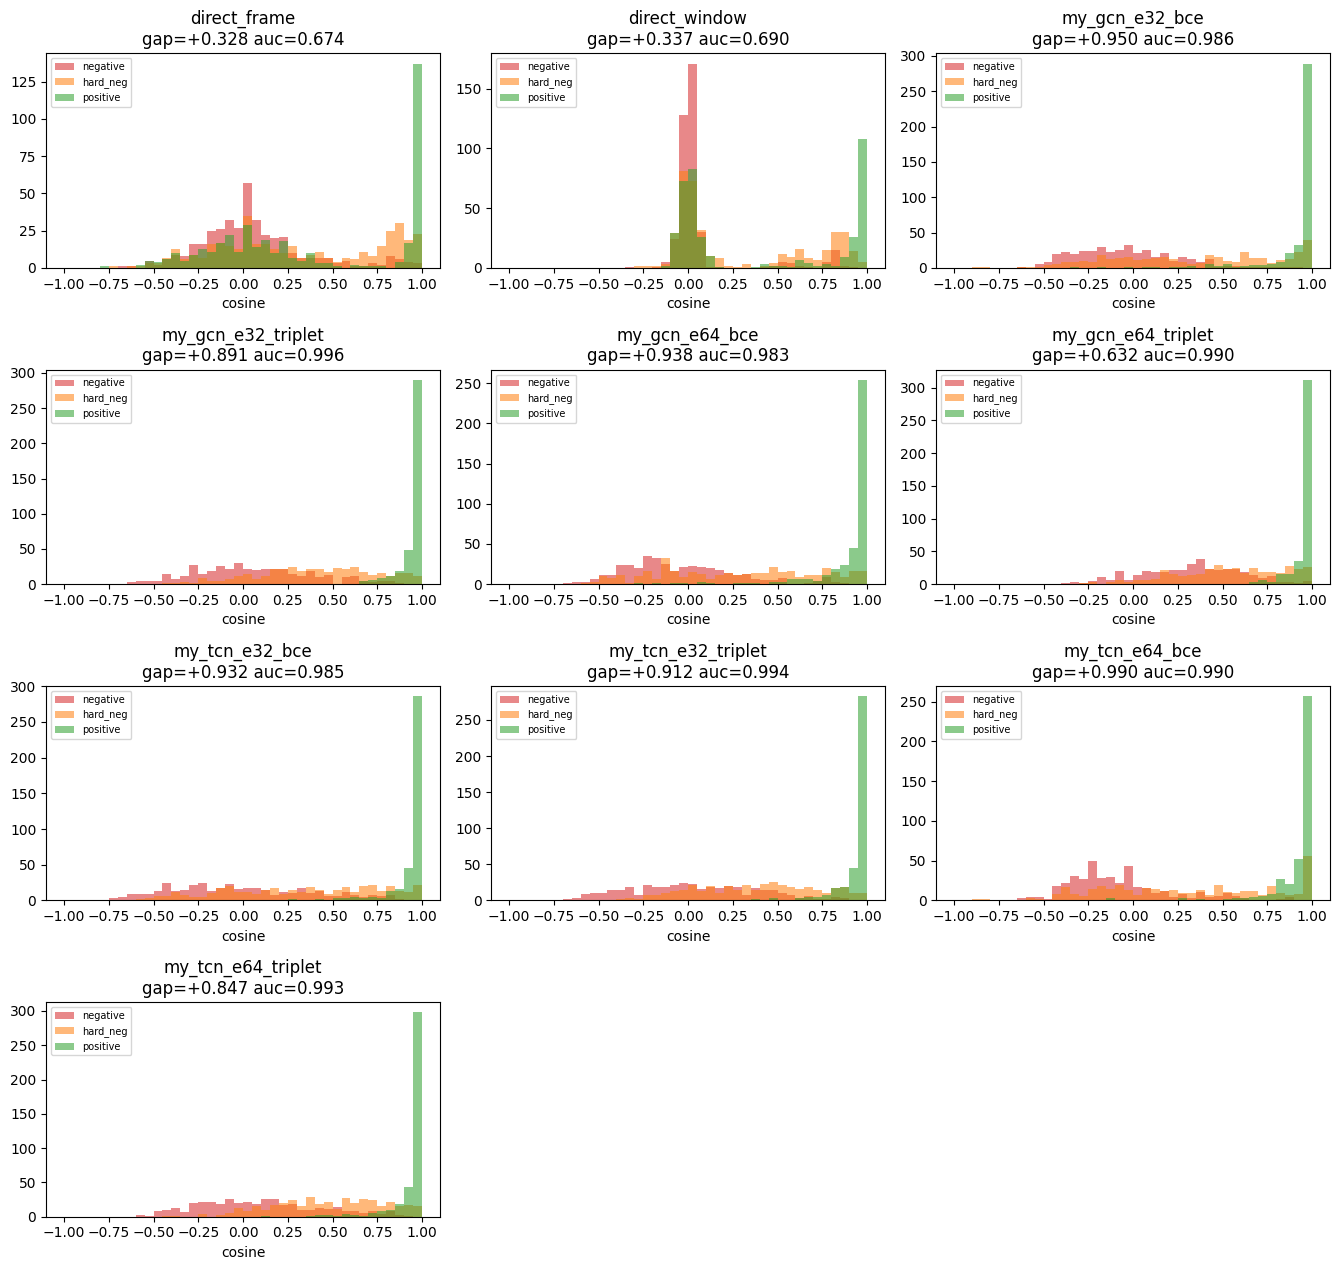

In [7]:
# --- Positive vs Negative cosine 분포 히스토그램 ---
n = len(results_pair)
cols = min(3, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.2 * rows), squeeze=False)
bins = np.linspace(-1.0, 1.0, 41)
for ax, (name, r) in zip(axes.ravel(), results_pair.items()):
    ax.hist(r['neg'], bins=bins, alpha=0.55, label='negative', color='tab:red')
    ax.hist(r['hneg'], bins=bins, alpha=0.55, label='hard_neg', color='tab:orange')
    ax.hist(r['pos'], bins=bins, alpha=0.55, label='positive', color='tab:green')
    ax.set_title(f"{name}\ngap={r['gap']:+.3f} auc={r['auc']:.3f}"
                 if r['auc'] is not None else
                 f"{name}\ngap={r['gap']:+.3f}")
    ax.set_xlabel('cosine')
    ax.legend(fontsize=7, loc='upper left')
for ax in axes.ravel()[len(results_pair):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. 지표 2 — Temporal Smoothness

**무엇을 보나**: embedding이 motion의 연속성을 보존하는가.

각 춤의 held-out 구간에서 stride=1로 연속된 window를 뽑아 `cos(E(t), E(t+k))` 를 계산한다. k가 작으면 embedding이 거의 같아야 하고 (cos ≈ 1), k가 커질수록 매끈하게 감소하는 게 좋은 embedding이다.

- k=1 (0.033s): 거의 동일한 자세 → 0.99 근처
- k=15 (0.5s): 동작이 조금 움직임 → 0.8~0.9
- k=120 (4s): 다른 구간일 가능성 → 많이 낮아짐

완전히 랜덤한 embedding은 k=1에서도 cos이 낮을 것. 학습이 실패한 신호.

In [8]:
def compute_temporal_smoothness(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    ks = EVAL['smoothness_ks']
    max_k = max(ks)

    per_k_cosines = {k: [] for k in ks}
    for d, seq in references.items():
        split = int(len(seq) * EVAL['train_ratio'])
        segment_lo = max(split, seq_length - 1)
        segment_hi = min(len(seq) - 1, segment_lo + EVAL['smoothness_segment_length'] - 1)
        if segment_hi - segment_lo < max_k + 1:
            continue
        ends = list(range(segment_lo, segment_hi + 1))
        embs = np.stack([
            method['embed'](make_window(d, e, seq_length, feat_dims))
            for e in ends
        ])  # (N, D), l2-normalized
        for k in ks:
            if len(embs) <= k:
                continue
            cos_k = (embs[:-k] * embs[k:]).sum(axis=-1)
            per_k_cosines[k].extend(cos_k.tolist())

    return {k: float(np.mean(per_k_cosines[k])) if per_k_cosines[k] else float('nan')
            for k in ks}


results_smooth = {}
for method in methods:
    results_smooth[method['name']] = compute_temporal_smoothness(method)
    row = results_smooth[method['name']]
    row_str = '  '.join(f'k={k}:{v:+.3f}' for k, v in row.items())
    print(f'  {method["name"]:30s}  {row_str}')

  direct_frame                    k=1:+0.327  k=5:+0.301  k=15:+0.266  k=30:+0.258  k=60:+0.230  k=120:+0.230
  direct_window                   k=1:+0.332  k=5:+0.303  k=15:+0.247  k=30:+0.251  k=60:+0.223  k=120:+0.215
  my_gcn_e32_bce                  k=1:+0.979  k=5:+0.880  k=15:+0.661  k=30:+0.428  k=60:+0.305  k=120:+0.223
  my_gcn_e32_triplet              k=1:+0.986  k=5:+0.912  k=15:+0.718  k=30:+0.491  k=60:+0.350  k=120:+0.402
  my_gcn_e64_bce                  k=1:+0.979  k=5:+0.840  k=15:+0.546  k=30:+0.309  k=60:+0.184  k=120:+0.264
  my_gcn_e64_triplet              k=1:+0.991  k=5:+0.918  k=15:+0.746  k=30:+0.579  k=60:+0.466  k=120:+0.416
  my_tcn_e32_bce                  k=1:+0.981  k=5:+0.881  k=15:+0.595  k=30:+0.303  k=60:+0.252  k=120:+0.181
  my_tcn_e32_triplet              k=1:+0.984  k=5:+0.905  k=15:+0.675  k=30:+0.409  k=60:+0.330  k=120:+0.269
  my_tcn_e64_bce                  k=1:+0.984  k=5:+0.866  k=15:+0.516  k=30:+0.368  k=60:+0.246  k=120:+0.152
  my_tcn_e

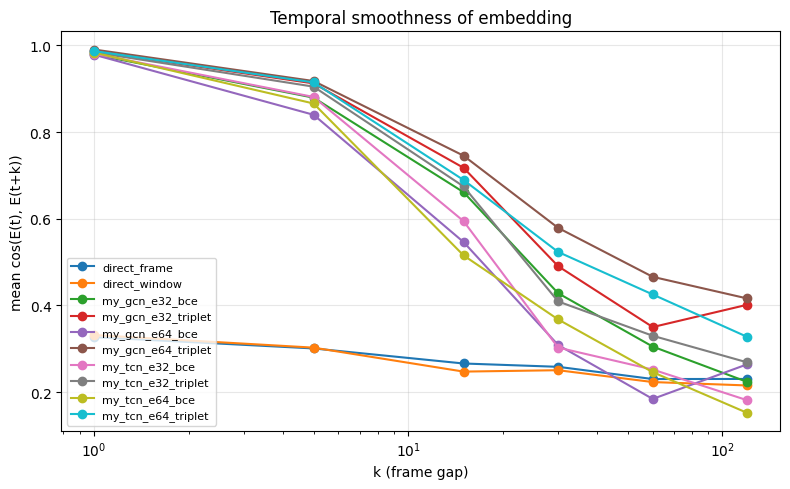

In [9]:
# --- Temporal decay curve ---
fig, ax = plt.subplots(figsize=(8, 5))
for name, row in results_smooth.items():
    ks = list(row.keys())
    vals = [row[k] for k in ks]
    ax.plot(ks, vals, marker='o', label=name)
ax.set_xlabel('k (frame gap)')
ax.set_ylabel('mean cos(E(t), E(t+k))')
ax.set_title('Temporal smoothness of embedding')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## 7. 지표 3 — Noise Robustness

**무엇을 보나**: 실 서비스의 MediaPipe 출력에는 frame-wise jitter가 있다. 훈련 시 noise_std=0.015 정도가 첨가됐는데, embedding이 실제로 노이즈에 robust한지 더 다양한 σ에서 검증한다.

각 held-out window W에 대해:
1. `E_clean = embed(W)`
2. `E_noisy = embed(W + N(0, σ))`
3. `cos(E_clean, E_noisy)` 평균

좋은 embedding은 σ가 커져도 cos이 높게 유지된다. σ=0.05 (학습 σ의 3배)에서 0.9 이상이면 양호.

In [10]:
def compute_noise_robustness(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    sigmas = EVAL['noise_sigmas']

    # 로컬 rng — method마다 같은 window/같은 noise pattern 사용
    local_rng = np.random.default_rng(EVAL['seed'] + 999)

    dances = list(references.keys())
    per_dance = max(1, EVAL['n_noise_windows'] // len(dances) + 1)
    samples = []
    for d in dances:
        er = valid_eval_end_range(d, seq_length)
        if er is None:
            continue
        lo, hi = er
        for _ in range(per_dance):
            end = int(local_rng.integers(lo, hi + 1))
            samples.append(make_window(d, end, seq_length, feat_dims))
    samples = samples[:EVAL['n_noise_windows']]

    e_clean = np.stack([method['embed'](w) for w in samples])  # (N, D)

    result = {}
    for sigma in sigmas:
        cos_list = []
        for i, w in enumerate(samples):
            noise_rng = np.random.default_rng(EVAL['seed'] + 10000 + i)
            w_noisy = w + noise_rng.normal(0.0, sigma, w.shape).astype(np.float32)
            e_noisy = method['embed'](w_noisy)
            cos_list.append(float(np.dot(e_clean[i], e_noisy)))
        result[sigma] = float(np.mean(cos_list))
    return result


results_noise = {}
for method in methods:
    results_noise[method['name']] = compute_noise_robustness(method)
    row = results_noise[method['name']]
    row_str = '  '.join(f'σ={s:.2f}:{v:+.3f}' for s, v in row.items())
    print(f'  {method["name"]:30s}  {row_str}')

  direct_frame                    σ=0.01:+1.000  σ=0.03:+0.999  σ=0.05:+0.998  σ=0.10:+0.991
  direct_window                   σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.995
  my_gcn_e32_bce                  σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  my_gcn_e32_triplet              σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.997
  my_gcn_e64_bce                  σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  my_gcn_e64_triplet              σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+1.000  σ=0.10:+0.998
  my_tcn_e32_bce                  σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  my_tcn_e32_triplet              σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+0.999  σ=0.10:+0.998
  my_tcn_e64_bce                  σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+1.000  σ=0.10:+0.998
  my_tcn_e64_triplet              σ=0.01:+1.000  σ=0.03:+1.000  σ=0.05:+1.000  σ=0.10:+0.999


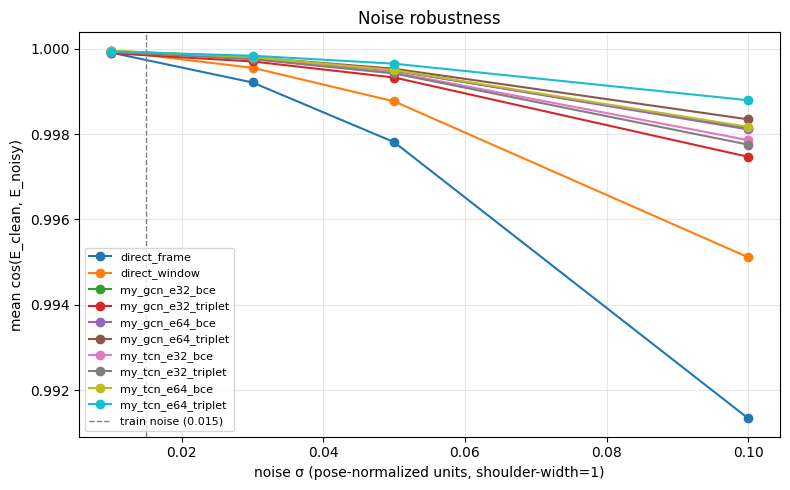

In [11]:
# --- Noise robustness curve ---
fig, ax = plt.subplots(figsize=(8, 5))
for name, row in results_noise.items():
    sigmas = list(row.keys())
    vals = [row[s] for s in sigmas]
    ax.plot(sigmas, vals, marker='o', label=name)
ax.axvline(0.015, color='gray', linestyle='--', linewidth=1, label='train noise (0.015)')
ax.set_xlabel('noise σ (pose-normalized units, shoulder-width=1)')
ax.set_ylabel('mean cos(E_clean, E_noisy)')
ax.set_title('Noise robustness')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
plt.show()

## 8. 지표 4 — Top-1 Retrieval (참고용)

**참고 지표**: 각 held-out query window에 대해 "5개 춤 중 어느 것인가" 를 per-dance max cosine 으로 맞힌다. 1에 가까울수록 좋음. pair discrimination이 충분히 좋으면 자동으로 top-1도 높게 나오므로 이중 확인용.

In [12]:
def compute_top1(method):
    seq_length = method['seq_len']
    feat_dims = method.get('feat_dims', EVAL['default_feat_dims'])
    dances = list(references.keys())

    gallery_emb, query_emb = {}, {}
    for d, seq in references.items():
        split = int(len(seq) * EVAL['train_ratio'])
        g_ends = list(range(seq_length - 1, split, EVAL['retrieval_gallery_stride']))
        q_ends = list(range(split + seq_length - 1, len(seq), EVAL['retrieval_query_stride']))
        gallery_emb[d] = (np.stack([method['embed'](make_window(d, e, seq_length, feat_dims))
                                    for e in g_ends])
                          if g_ends else None)
        query_emb[d] = (np.stack([method['embed'](make_window(d, e, seq_length, feat_dims))
                                  for e in q_ends])
                        if q_ends else None)

    n_correct, n_total = 0, 0
    for true_d in dances:
        queries = query_emb[true_d]
        if queries is None or len(queries) == 0:
            continue
        per_dance_max = []
        for cand_d in dances:
            gallery = gallery_emb[cand_d]
            if gallery is None or len(gallery) == 0:
                per_dance_max.append(np.full(len(queries), -np.inf))
            else:
                sims = queries @ gallery.T
                per_dance_max.append(sims.max(axis=1))
        stacked = np.stack(per_dance_max, axis=1)  # (Q, n_dances)
        preds = stacked.argmax(axis=1)
        true_idx = dances.index(true_d)
        n_correct += int((preds == true_idx).sum())
        n_total += len(queries)
    return n_correct / max(1, n_total)


results_top1 = {}
for method in methods:
    results_top1[method['name']] = compute_top1(method)
    print(f'  {method["name"]:30s}  top-1 = {results_top1[method["name"]]:.3f}')

  direct_frame                    top-1 = 0.409
  direct_window                   top-1 = 0.435
  my_gcn_e32_bce                  top-1 = 0.489
  my_gcn_e32_triplet              top-1 = 0.398
  my_gcn_e64_bce                  top-1 = 0.360
  my_gcn_e64_triplet              top-1 = 0.344
  my_tcn_e32_bce                  top-1 = 0.339
  my_tcn_e32_triplet              top-1 = 0.414
  my_tcn_e64_bce                  top-1 = 0.360
  my_tcn_e64_triplet              top-1 = 0.333


## 9. 종합 표

모든 지표를 한 표로 모아 비교한다. **GAP과 AUC가 가장 의미 있는 지표** (학습 목표 직접 측정). Smoothness는 k=15에서의 값, noise는 σ=0.05에서의 값이 대표.

In [13]:
header_cols = [
    ('METHOD', 30),
    ('LOSS', 8),
    ('POS', 7),
    ('NEG', 7),
    ('HARD', 7),
    ('GAP', 8),
    ('AUC', 6),
    ('SMOOTH_15', 10),
    ('NOISE_0.05', 11),
    ('TOP-1', 6),
]
header = '  '.join(f'{col:>{w}s}' if col != 'METHOD' else f'{col:<{w}s}'
                   for col, w in header_cols)
print(header)
print('-' * (sum(w for _, w in header_cols) + 2 * (len(header_cols) - 1)))

rows = []
for method in methods:
    name = method['name']
    r1 = results_pair[name]
    smooth = results_smooth[name].get(15, float('nan'))
    noise = results_noise[name].get(0.05, float('nan'))
    t1 = results_top1[name]
    auc_val = r1['auc']
    auc_str = f'{auc_val:.3f}' if (auc_val is not None and np.isfinite(auc_val)) else '  -  '
    row_vals = [
        f'{name:<30s}',
        f'{method["loss"]:>8s}',
        f'{r1["mean_pos"]:>+7.3f}',
        f'{r1["mean_neg"]:>+7.3f}',
        f'{r1["mean_hneg"]:>+7.3f}',
        f'{r1["gap"]:>+8.3f}',
        f'{auc_str:>6s}',
        f'{smooth:>+10.3f}',
        f'{noise:>+11.3f}',
        f'{t1:>6.3f}',
    ]
    print('  '.join(row_vals))
    rows.append({
        'name': name, 'loss': method['loss'],
        'pos': r1['mean_pos'], 'neg': r1['mean_neg'], 'hard_neg': r1['mean_hneg'],
        'gap': r1['gap'], 'auc': auc_val,
        'smooth_15': smooth, 'noise_05': noise, 'top1': t1,
    })

# 각 지표별 best 모델 하이라이트 (direct baseline 제외하고 순수 모델 간)
scratch_rows = [r for r in rows if not r['name'].startswith('direct_')]
if scratch_rows:
    print()
    def best_by(key, reverse=True):
        return max(scratch_rows, key=lambda r: r[key] if (r[key] is not None and np.isfinite(r[key])) else -np.inf) if reverse \
               else min(scratch_rows, key=lambda r: r[key] if (r[key] is not None and np.isfinite(r[key])) else np.inf)
    print(f'[BEST by gap]        {best_by("gap")["name"]}  ({best_by("gap")["gap"]:+.3f})')
    if any(r['auc'] is not None and np.isfinite(r['auc']) for r in scratch_rows):
        print(f'[BEST by auc]        {best_by("auc")["name"]}  ({best_by("auc")["auc"]:.3f})')
    print(f'[BEST by smoothness] {best_by("smooth_15")["name"]}  '
          f'({best_by("smooth_15")["smooth_15"]:+.3f})')
    print(f'[BEST by noise rob.] {best_by("noise_05")["name"]}  '
          f'({best_by("noise_05")["noise_05"]:+.3f})')
    print(f'[BEST by top-1]      {best_by("top1")["name"]}  ({best_by("top1")["top1"]:.3f})')


METHOD                              LOSS      POS      NEG     HARD       GAP     AUC   SMOOTH_15   NOISE_0.05   TOP-1
----------------------------------------------------------------------------------------------------------------------
direct_frame                           -   +0.387   +0.060   +0.309    +0.328   0.674      +0.266       +0.998   0.409
direct_window                          -   +0.407   +0.069   +0.294    +0.337   0.690      +0.247       +0.999   0.435
my_gcn_e32_bce                       bce   +0.917   -0.034   +0.337    +0.950   0.986      +0.661       +0.999   0.489
my_gcn_e32_triplet               triplet   +0.951   +0.059   +0.410    +0.891   0.996      +0.718       +0.999   0.398
my_gcn_e64_bce                       bce   +0.902   -0.036   +0.286    +0.938   0.983      +0.546       +0.999   0.360
my_gcn_e64_triplet               triplet   +0.960   +0.327   +0.534    +0.632   0.990      +0.746       +1.000   0.344
my_tcn_e32_bce                       bce   +0.93

## 10. 해석 가이드

- **`GAP`이 클수록** pair 수준에서 같은 동작과 다른 동작이 확실히 벌어진다 → 서비스에서 점수 해상도가 높다.
- **`AUC`가 1에 가까울수록** cosine threshold를 어디에 잡든 분류가 잘 된다 → tolerance 파라미터에 덜 민감.
- **`HARD_NEG`가 `POS`와 비슷하면** 모델이 같은 춤 내부 다른 구간을 구분 못 함. 게임에서 "아무 포즈나 취해도 점수 나옴" 리스크.
- **`SMOOTH_15`이 0.7 이하**면 0.5초 이웃이 다르게 보인다는 뜻 → 점수가 튀어 gameplay가 피곤.
- **`NOISE_0.05`가 0.9 이하**면 MediaPipe jitter만으로 embedding이 크게 흔들림 → 실서비스에서 불안정.

### 이상적인 프로필

```
POS ≈ +0.95, NEG ≈ −0.2, HARD_NEG ≈ +0.3
GAP ≈ +1.1, AUC ≈ 0.98
SMOOTH_15 ≈ +0.9, NOISE_0.05 ≈ +0.96
TOP-1 ≈ 0.95
```

직접 baseline (`direct_*`) 과 비교해서 위 모든 축에서 학습 모델이 **의미 있게 좋아야** 서비스로 쓸 가치가 있다. 특히 `GAP`과 `NOISE_0.05`에서 direct보다 낫지 않으면 학습이 값어치를 못 한 것.